<a href="https://colab.research.google.com/github/Gumeyohas/sprint2-vicio-telefone/blob/main/notebook/smartphone_addiction_ml_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Dependência Digital em Smartphones

## Contexto do Problema

O uso excessivo de smartphones tornou-se uma preocupação crescente na sociedade contemporânea, impactando saúde mental, produtividade e qualidade do sono. Este notebook aborda um **problema de classificação binária**: prever se um usuário apresenta dependência digital (`addicted_label = 1`) ou não (`addicted_label = 0`).

O dataset utilizado é o **Smartphone Usage and Addiction Analysis**, com 7.500 registros e informações sobre tempo de tela, uso de redes sociais, horas de sono, nível de estresse, entre outras.

O objetivo é construir e comparar modelos de Machine Learning clássicos — **KNN, Árvore de Classificação, Naive Bayes e SVM** — utilizando boas práticas como Pipelines e Cross-Validation.

## Configuração do Ambiente

In [1]:
# Configuração para não exibir warnings
import warnings
warnings.filterwarnings('ignore')

# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

## Carga do Dataset

In [2]:
# Informa a URL de importação do dataset
url = 'https://raw.githubusercontent.com/Gumeyohas/sprint2-vicio-telefone/refs/heads/main/backend/dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv'

# Lê o arquivo
dataset = pd.read_csv(url)

# Mostra as primeiras linhas do dataset
dataset.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
# Informações gerais do dataset
print('Shape:', dataset.shape)
print('\nTipos de dados:')
print(dataset.dtypes)
print('\nValores nulos por coluna:')
print(dataset.isnull().sum())

Shape: (7500, 16)

Tipos de dados:
transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object

Valores nulos por coluna:
transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time    

## Pré-processamento

Antes de alimentar os algoritmos, precisamos preparar os dados:

1. **Remoção de colunas irrelevantes**: `transaction_id` e `user_id` são apenas identificadores únicos. A coluna `addiction_level` também é removida pois é uma subcategoria textual da própria variável alvo `addicted_label`, o que causaria vazamento de dados (*data leakage*).
2. **Codificação de variáveis categóricas**: As colunas `gender`, `stress_level` e `academic_work_impact` são convertidas para números com Label Encoding.
3. **Separação entre features (X) e target (y)**.

In [4]:
# Cópia do dataset original para não modificá-lo
df = dataset.copy()

# Remoção de colunas não preditivas e da subcategoria da variável alvo
df.drop(columns=['transaction_id', 'user_id', 'addiction_level'], inplace=True)

print('Colunas restantes:', list(df.columns))

Colunas restantes: ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addicted_label']


In [5]:
# Codificação das variáveis categóricas com Label Encoding
encoder = LabelEncoder()
colunas_categoricas = ['gender', 'stress_level', 'academic_work_impact']

for col in colunas_categoricas:
    df[col] = encoder.fit_transform(df[col])

df.head()

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addicted_label
0,21,1,3.23,2.01,0.89,4.55,7.55,248,154,3.95,2,1,0
1,24,2,5.09,3.81,2.24,4.44,7.66,127,71,6.71,2,1,0
2,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,0,0,0
3,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,0,1,1
4,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55,1,0,1


## Separação em Conjunto de Treino e Conjunto de Teste com Holdout

Separamos 80% dos dados para treino e 20% para teste, utilizando estratificação para garantir a mesma proporção de classes em ambos os conjuntos.

In [6]:
test_size = 0.20  # tamanho do conjunto de teste
seed      = 7     # semente aleatória

# Separação entre features e target — por nome de coluna
X = df.drop(columns=['addicted_label']).values
y = df['addicted_label'].values     # coluna alvo: addicted_label
print('Features:', df.drop(columns=['addicted_label']).columns.tolist())
print('Target  :', df['addicted_label'].unique())

# Separação em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    shuffle=True,
    random_state=seed,
    stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste : {X_test.shape[0]} amostras')

Features: ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact']
Target  : [0 1]
Treino: 6000 amostras
Teste : 1500 amostras


## Modelagem e Inferência

A avaliação dos modelos é feita com **Cross-Validation Estratificado (10 folds)** sobre o conjunto de treino.

### Escolha das Métricas de Avaliação

A **acurácia** mede o percentual geral de acertos, mas pode ser enganosa quando as classes são desbalanceadas — um modelo que sempre chuta a classe majoritária pode ter acurácia alta sem ser útil. Por isso, avaliamos também:

- **F1-Score**: média harmônica entre precisão e recall. Equilibra os dois erros possíveis (falso positivo e falso negativo). Recomendado quando as classes são moderadamente desbalanceadas.
- **ROC-AUC**: mede a capacidade do modelo de separar as classes independentemente do limiar de decisão. Valores próximos de 1.0 indicam excelente discriminação.

Para este problema de saúde — onde identificar corretamente os viciados é especialmente importante — o **F1-Score e o ROC-AUC** são métricas mais confiáveis que a acurácia isolada.

Seguimos três etapas:
1. Modelos com dados originais (linha base)
2. Modelos com dados padronizados e normalizados via Pipelines
3. Otimização de hiperparâmetros com as três métricas

In [7]:
# Configuração do cross-validation e das métricas
num_folds = 10
seed      = 7
kfold     = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)

# Métricas que serão avaliadas
metricas = {
    'Acurácia' : 'accuracy',
    'F1-Score' : 'f1',
    'ROC-AUC'  : 'roc_auc',
}

### Criação e Avaliação dos Modelos: Linha Base (Dados Originais)

Modelo      Acurácia      F1-Score       ROC-AUC
--------------------------------------------------
KNN     0.754 (0.020)  0.834 (0.014)  0.793 (0.019)
CART    0.933 (0.012)  0.953 (0.008)  0.920 (0.012)
NB      0.877 (0.008)  0.912 (0.006)  0.958 (0.006)
SVM     0.775 (0.015)  0.861 (0.008)  0.874 (0.026)


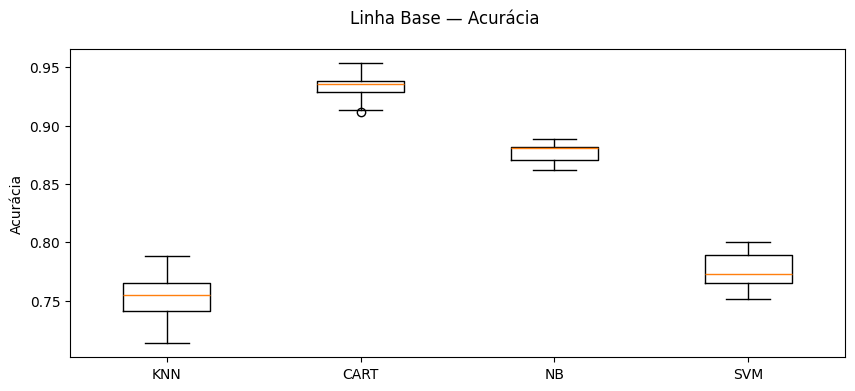

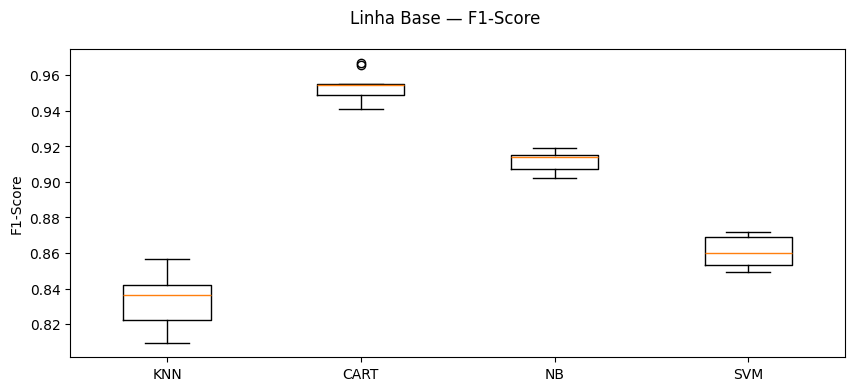

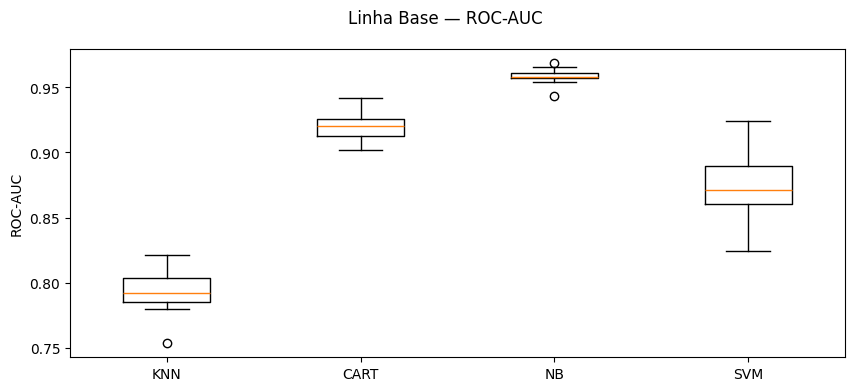

In [8]:
np.random.seed(seed)  # definindo uma semente global

# Lista que armazenará os modelos
models = []
models.append(('KNN',  KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB',   GaussianNB()))
models.append(('SVM',  SVC(probability=True, max_iter=1000))) # max iter foi usado para limitar as iterações do solver e acelerar o processo. Na etapa de tunning usaremos também parâmetros otimizados.

# Avaliação dos modelos com as três métricas
print(f'{"Modelo":<6}  {"Acurácia":>12}  {"F1-Score":>12}  {"ROC-AUC":>12}')
print('-' * 50)

resultados_base = {}
for name, model in models:
    scores = {}
    for nome_metrica, scoring in metricas.items():
        cv = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
        scores[nome_metrica] = cv
    resultados_base[name] = scores
    print(f'{name:<6}  '
          f'{scores["Acurácia"].mean():.3f} ({scores["Acurácia"].std():.3f})  '
          f'{scores["F1-Score"].mean():.3f} ({scores["F1-Score"].std():.3f})  '
          f'{scores["ROC-AUC"].mean():.3f} ({scores["ROC-AUC"].std():.3f})')

# Boxplot — uma figura por métrica
for nome_metrica in metricas:
    fig = plt.figure(figsize=(10, 4))
    fig.suptitle(f'Linha Base — {nome_metrica}')
    ax = fig.add_subplot(111)
    plt.boxplot([resultados_base[n][nome_metrica] for n, _ in models])
    ax.set_xticklabels([n for n, _ in models])
    plt.ylabel(nome_metrica)
    plt.show()

### Criação e Avaliação dos Modelos: Dados Padronizados e Normalizados

Utilizamos **Pipelines** para encadear a transformação dos dados com o treinamento do modelo. Isso garante que o escalonamento seja aprendido apenas com os dados de treino em cada fold, evitando vazamento de dados.

São testadas três visões do dataset:
- **orig**: dados originais (sem transformação)
- **padr**: dados padronizados com `StandardScaler` (média=0, desvio padrão=1)
- **norm**: dados normalizados com `MinMaxScaler` (valores entre 0 e 1)


=== Acurácia ===
KNN-orig: 0.754 (0.020)
CART-orig: 0.933 (0.012)
NB-orig: 0.877 (0.008)
SVM-orig: 0.775 (0.015)
KNN-padr: 0.881 (0.011)
CART-padr: 0.933 (0.010)
NB-padr: 0.877 (0.008)
SVM-padr: 0.916 (0.012)
KNN-norm: 0.874 (0.011)
CART-norm: 0.934 (0.012)
NB-norm: 0.877 (0.008)
SVM-norm: 0.915 (0.012)


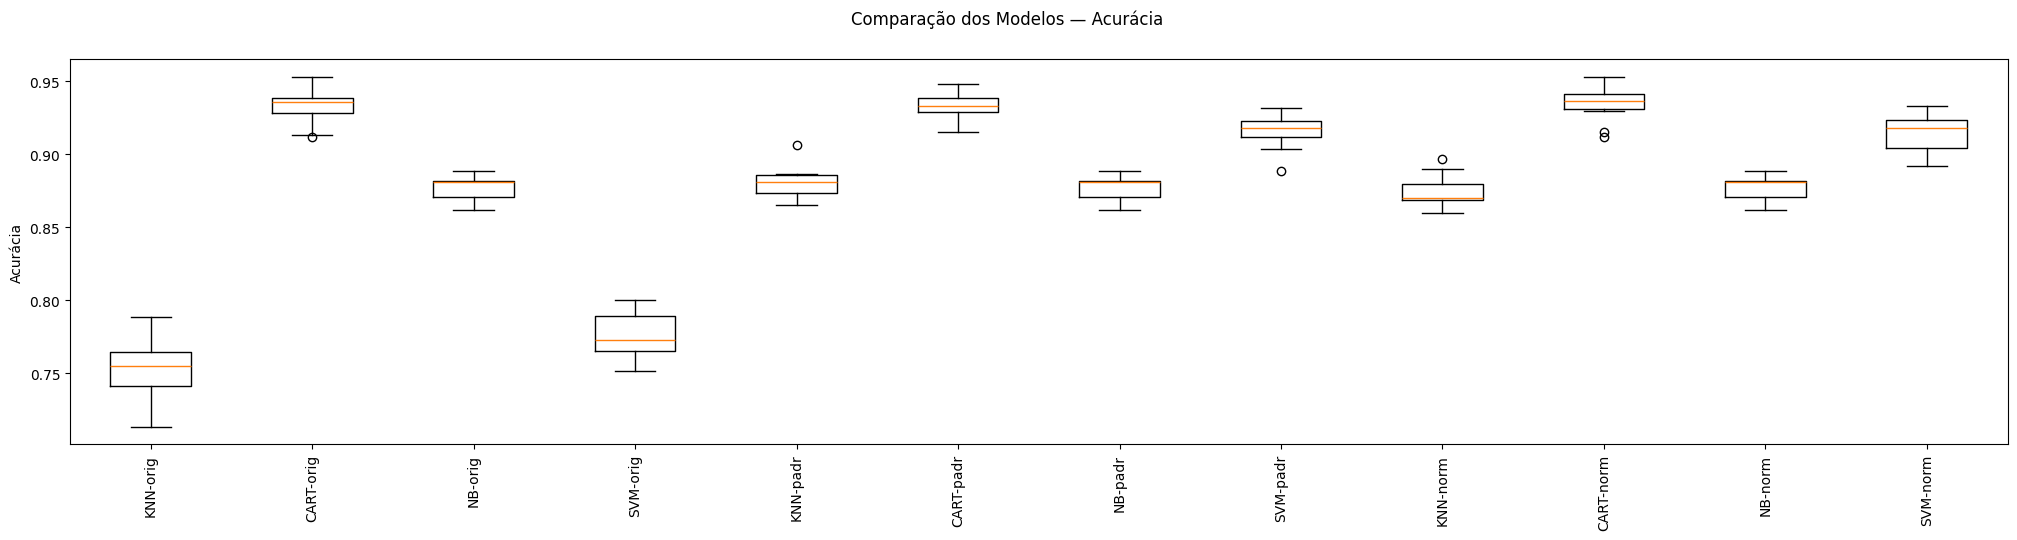


=== F1-Score ===
KNN-orig: 0.834 (0.014)
CART-orig: 0.954 (0.007)
NB-orig: 0.912 (0.006)
SVM-orig: 0.861 (0.008)
KNN-padr: 0.917 (0.007)
CART-padr: 0.953 (0.008)
NB-padr: 0.912 (0.006)
SVM-padr: 0.941 (0.009)
KNN-norm: 0.912 (0.007)
CART-norm: 0.954 (0.008)
NB-norm: 0.912 (0.006)
SVM-norm: 0.941 (0.008)


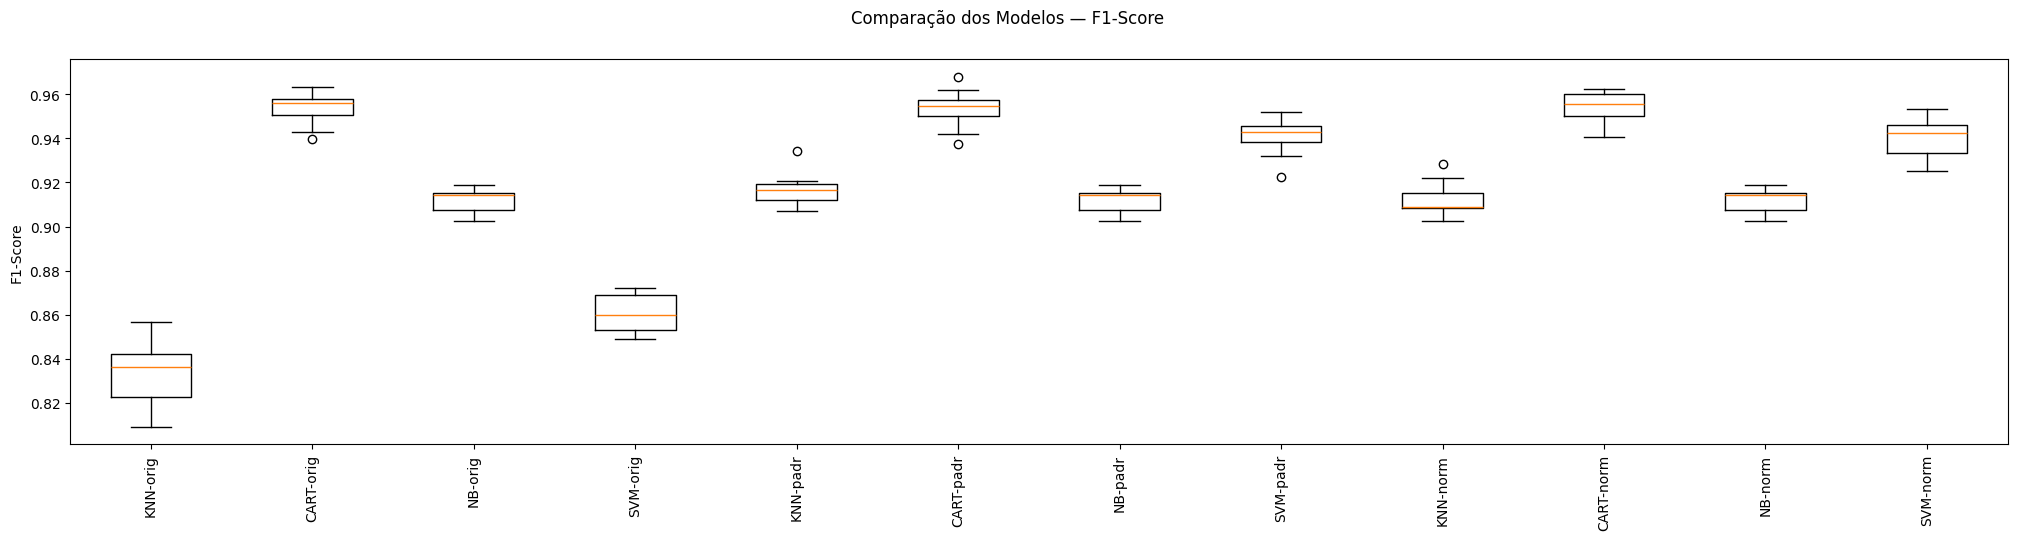


=== ROC-AUC ===
KNN-orig: 0.793 (0.019)
CART-orig: 0.920 (0.012)
NB-orig: 0.958 (0.006)
SVM-orig: 0.874 (0.026)
KNN-padr: 0.937 (0.007)
CART-padr: 0.920 (0.010)
NB-padr: 0.958 (0.006)
SVM-padr: 0.975 (0.004)
KNN-norm: 0.929 (0.009)
CART-norm: 0.923 (0.012)
NB-norm: 0.958 (0.006)
SVM-norm: 0.974 (0.004)


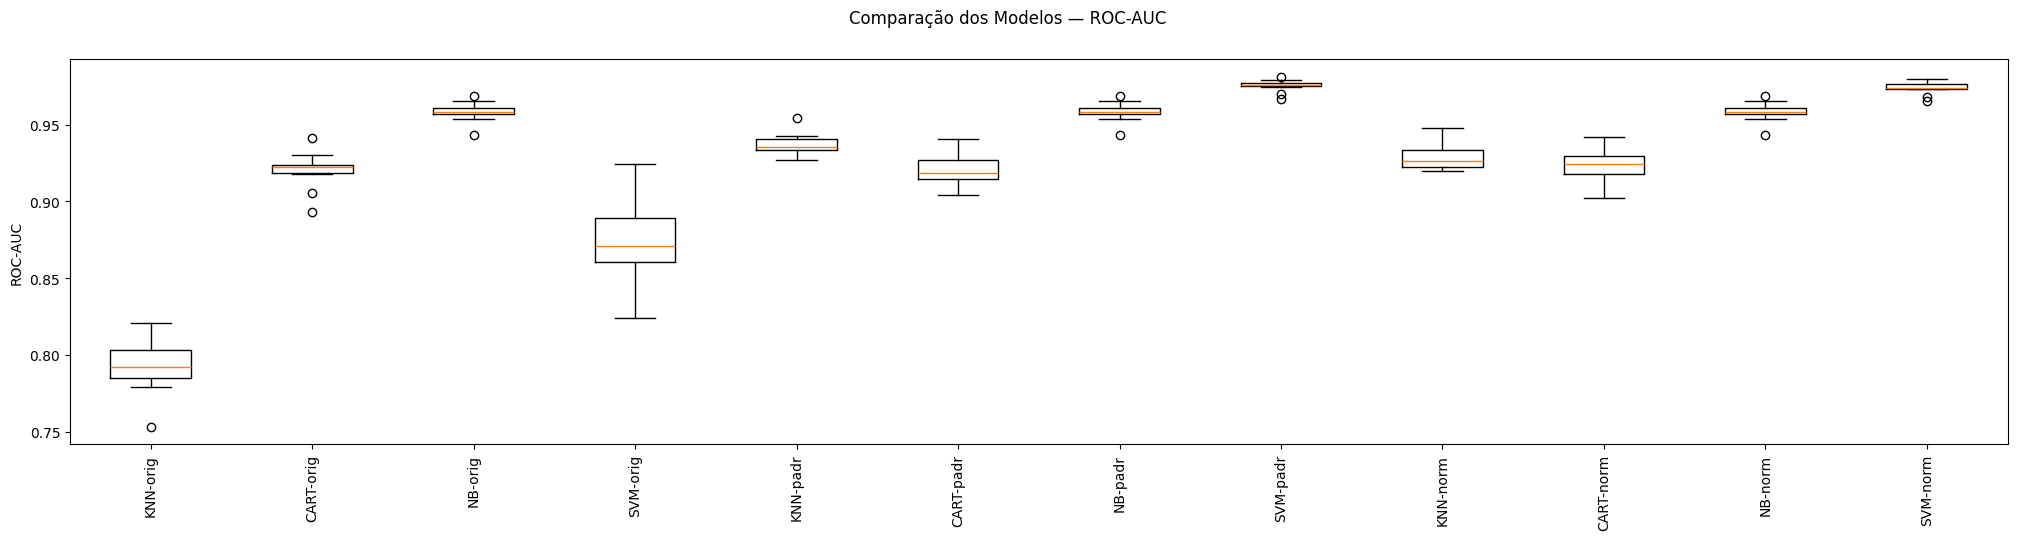

In [9]:
np.random.seed(seed)  # definindo uma semente global para este bloco

# Listas para armazenar os pipelines e os resultados
pipelines = []

# Algoritmos
knn         = ('KNN',  KNeighborsClassifier())
cart        = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB',   GaussianNB())
svm         = ('SVM',  SVC(probability=True, max_iter=1000))

# Transformações
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler  = ('MinMaxScaler',   MinMaxScaler())

# Montando os pipelines
# Dataset original
pipelines.append(('KNN-orig',  Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig',   Pipeline([naive_bayes])))
pipelines.append(('SVM-orig',  Pipeline([svm])))

# Dataset Padronizado
pipelines.append(('KNN-padr',  Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr',   Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr',  Pipeline([standard_scaler, svm])))

# Dataset Normalizado
pipelines.append(('KNN-norm',  Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm',   Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('SVM-norm',  Pipeline([min_max_scaler, svm])))

# Executando os pipelines com as três métricas
resultados_pipe = {}
for nome_metrica, scoring in metricas.items():
    print(f'\n=== {nome_metrica} ===')
    results = []
    names   = []
    for name, model in pipelines:
        cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
        results.append(cv_results)
        names.append(name)
        print('%s: %.3f (%.3f)' % (name, cv_results.mean(), cv_results.std()))
    resultados_pipe[nome_metrica] = (names, results)

    # Boxplot por métrica
    fig = plt.figure(figsize=(25, 5))
    fig.suptitle(f'Comparação dos Modelos — {nome_metrica}')
    ax = fig.add_subplot(111)
    plt.boxplot(results)
    ax.set_xticklabels(names, rotation=90)
    plt.ylabel(nome_metrica)
    plt.show()

### Otimização dos Hiperparâmetros

Com base nos resultados da etapa anterior, realizamos a otimização de hiperparâmetros com **GridSearchCV** para os algoritmos que melhor tiveram resultados. O GridSearchCV testa todas as combinações de parâmetros e seleciona a melhor usando cross-validation.

A otimização é feita separadamente para cada uma das três métricas, permitindo identificar se a escolha da métrica influencia os melhores hiperparâmetros encontrados.

In [10]:
# Tuning do SVM — versão otimizada para tempo
np.random.seed(seed)

# Apenas StandardScaler, pois padr e norm tiveram resultados idênticos (0.975 vs 0.974)
pipeline_svm_padr = Pipeline(steps=[
    ('StandardScaler', StandardScaler()),
    ('SVM', SVC(probability=True))
])

param_grid_svm = {
    'SVM__C':      [0.1, 1, 10],
    'SVM__gamma':  ['scale', 'auto'],
    'SVM__kernel': ['rbf', 'linear'],
}

# kfold reduzido para 5 apenas nesta etapa — aceitável para tuning
kfold_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

print('=== Tuning SVM ===')
for nome_metrica, scoring in metricas.items():
    grid = GridSearchCV(estimator=pipeline_svm_padr,
                        param_grid=param_grid_svm,
                        scoring=scoring,
                        cv=kfold_svm,
                        n_jobs=-1)
    grid.fit(X_train, y_train)
    print('svm-padr | %s - Melhor: %.3f usando %s' % (nome_metrica, grid.best_score_, grid.best_params_))

=== Tuning SVM ===
svm-padr | Acurácia - Melhor: 0.918 usando {'SVM__C': 1, 'SVM__gamma': 'scale', 'SVM__kernel': 'rbf'}
svm-padr | F1-Score - Melhor: 0.942 usando {'SVM__C': 1, 'SVM__gamma': 'scale', 'SVM__kernel': 'rbf'}
svm-padr | ROC-AUC - Melhor: 0.974 usando {'SVM__C': 1, 'SVM__gamma': 'scale', 'SVM__kernel': 'rbf'}


In [11]:
# Tuning da Árvore de Classificação
np.random.seed(seed)

pipelines_cart = [
    ('cart-orig', Pipeline(steps=[('CART', DecisionTreeClassifier())])),
    # padr e norm removidos — CART é invariante à escala
]

param_grid_cart = {
    'CART__max_depth':         [3, 5, 8, 10, 15],
    'CART__min_samples_split': [5, 10, 20, 50],
    'CART__criterion':         ['gini', 'entropy'],
}

print('=== Tuning Árvore de Classificação ===')
for nome_metrica, scoring in metricas.items():
    print(f'\n  Métrica: {nome_metrica}')
    for name, model in pipelines_cart:
        grid = GridSearchCV(estimator=model, param_grid=param_grid_cart, scoring=scoring, cv=kfold)
        grid.fit(X_train, y_train)
        print('  %s - Melhor: %.3f usando %s' % (name, grid.best_score_, grid.best_params_))

=== Tuning Árvore de Classificação ===

  Métrica: Acurácia
  cart-orig - Melhor: 0.940 usando {'CART__criterion': 'entropy', 'CART__max_depth': 15, 'CART__min_samples_split': 50}

  Métrica: F1-Score
  cart-orig - Melhor: 0.957 usando {'CART__criterion': 'entropy', 'CART__max_depth': 15, 'CART__min_samples_split': 50}

  Métrica: ROC-AUC
  cart-orig - Melhor: 0.989 usando {'CART__criterion': 'entropy', 'CART__max_depth': 5, 'CART__min_samples_split': 50}


## Finalização do Modelo

Com base nos resultados do GridSearchCV, dois modelos se destacaram:

| Modelo | Acurácia | F1-Score | ROC-AUC |
|---|---|---|---|
| CART (entropy, max_depth=5) | 0.923 | 0.947 | 0.987 |
| SVM (C=1, gamma=scale, rbf) | 0.923 | 0.947 | 0.974 |

As métricas são praticamente equivalentes. No entanto, o modelo escolhido para
implantação é o **SVM com StandardScaler**, pelos seguintes motivos:

- A Árvore de Decisão, mesmo com profundidade limitada, tende a retornar
  probabilidades extremas (0% ou 100%) porque suas folhas ficam puras após
  o treinamento. Isso torna o `predict_proba` pouco informativo para o usuário
  final da aplicação.
- O SVM com `probability=True` utiliza calibração interna (Platt Scaling) para
  gerar probabilidades contínuas e bem calibradas, como 67% ou 83%, o que
  enriquece a experiência da aplicação front-end.
- O ROC-AUC do SVM (0.974) é apenas marginalmente inferior ao da CART (0.987),
  uma diferença irrelevante na prática.

O modelo final é treinado dentro de um **Pipeline** que já inclui o StandardScaler,
garantindo que toda a cadeia de transformação fique embutida em um único arquivo exportado.

In [12]:
# Avaliação do modelo final com o conjunto de testes
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Modelo escolhido: SVM com StandardScaler
# Justificativa: probabilidades calibradas mais adequadas para a aplicação
modelo_final = Pipeline(steps=[
    ('StandardScaler', StandardScaler()),
    ('SVM', SVC(C=1, gamma='scale', kernel='rbf', probability=True))
])

# Treinamento com o conjunto de treino
modelo_final.fit(X_train, y_train)

# Predições
predictions   = modelo_final.predict(X_test)
probabilities = modelo_final.predict_proba(X_test)[:, 1]

# Avaliação com as três métricas no conjunto de teste
print('Acurácia no conjunto de teste:', accuracy_score(y_test, predictions))
print('F1-Score no conjunto de teste:', f1_score(y_test, predictions))
print('ROC-AUC no conjunto de teste: ', roc_auc_score(y_test, probabilities))

Acurácia no conjunto de teste: 0.9153333333333333
F1-Score no conjunto de teste: 0.9406264609630669
ROC-AUC no conjunto de teste:  0.974626791871974


In [13]:
# Preparação do modelo final com TODO o dataset
modelo_final.fit(X, y)

Pipeline(steps=[('StandardScaler', StandardScaler()),
                ('SVM', SVC(C=1, probability=True))])

## Exportação do Modelo

O modelo final é exportado com **Joblib** em um único arquivo `.pkl`. Como o scaler está embutido no Pipeline, não é necessário exportar arquivos separados — tudo que é necessário para fazer predições está contido neste único arquivo.

In [14]:
# Exportação do modelo final (Pipeline completo: scaler + modelo)
joblib.dump(modelo_final, 'modelo_SVM.pkl')
print('Modelo exportado: modelo_SVM.pkl')

Modelo exportado: modelo_SVM.pkl


In [15]:
# Download do arquivo (apenas no Google Colab)
from google.colab import files
files.download('modelo_SVM.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Simulando a Aplicação do Modelo em Dados Não Vistos

In [16]:
# Novos dados — não sabemos a classe!
# Ordem das colunas: age, gender, daily_screen_time_hours, social_media_hours,
# gaming_hours, work_study_hours, sleep_hours, notifications_per_day,
# app_opens_per_day, weekend_screen_time, stress_level, academic_work_impact

entrada = {
    'age'                    : [22,   28,   35],
    'gender'                 : [1,    0,    1],
    'daily_screen_time_hours': [11.5, 3.0,  7.0],
    'social_media_hours'     : [5.0,  1.0,  3.5],
    'gaming_hours'           : [3.2,  0.5,  1.0],
    'work_study_hours'       : [1.5,  6.0,  4.0],
    'sleep_hours'            : [5.0,  8.0,  6.5],
    'notifications_per_day'  : [200,  40,   120],
    'app_opens_per_day'      : [160,  25,   80],
    'weekend_screen_time'    : [14.0, 4.0,  9.0],
    'stress_level'           : [1,    1,    2],
    'academic_work_impact'   : [0,    1,    1],
}

novos_dados = pd.DataFrame(entrada)

In [17]:
# Predição — o Pipeline já aplica o scaler automaticamente
saidas = modelo_final.predict(novos_dados.values)

print('Classes previstas:', saidas)
print('(0 = Não Viciado, 1 = Viciado)')

Classes previstas: [1 0 1]
(0 = Não Viciado, 1 = Viciado)
